In [49]:
from typing import List, Tuple
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from matplotlib.table import Table
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import struct
import os
import cupy as cp
import re
import json


def create_line_graph(ys: np.ndarray, names: List[str]) -> Tuple[Figure, Axes]:

    fig: Figure = plt.figure(figsize=(15, 8))
    axes: Axes = fig.add_subplot(111)


    xs = np.arange(0, ys.shape[1] * 500, 500)

    for y, name in zip(ys, names):
        axes.plot(xs, y, label=name)
    axes.set_xlabel("Iterations")
    axes.set_ylabel("PSNR (in dB)")
    axes.legend()
    return fig, axes

In [26]:
# Load validation_results.txt
res_array = [{}, {}, {}, {}, {}]


with open("validation_results.txt", "r") as file:
    #path,mse,psnr,loss,ema,total training time,mse_series,psnr_series
    line_pattern = r"(?P<path>[/.\d\w_-]+),mse:(?P<mse>[\d.]+),psnr:(?P<psnr>[\d.]+) dB,loss:(?P<loss>[\d.]+),ema:(?P<ema>[\d.]+),total training time: (?P<time>[\d.]+),mse_series:\[(?P<mse_series>[\d., ]+)\],psnr_series:\[(?P<psnr_series>[\d., ]+)\]"
    i = 0
    results = res_array[i]
    for line in file:
        match = re.match(line_pattern, line)
        if(match == None): continue
        groups = match.groupdict()
        name = groups["path"]
        mse = float(groups["mse"])
        psnr = float(groups["psnr"])
        loss = float(groups["loss"])
        ema = float(groups["ema"])
        time = float(groups["time"])
        mse_series_str = groups["mse_series"]
        psnr_series_str = groups["psnr_series"]
        mse_series = [float(i) for i in mse_series_str.split(",")]
        psnr_series = [float(i) for i in psnr_series_str.split(",")]
        name = name[name.rfind("/default_")+9:-5] # -5 for the .json
        results[name] = {
            "mse" :float(groups["mse"]),
            "psnr" :float(groups["psnr"]),
            "loss" :float(groups["loss"]),
            "ema" :float(groups["ema"]),
            "time" :float(groups["time"]),
            "mse_series": mse_series,
            "psnr_series": psnr_series
        }
        i += 1
        i %= 5
        results = res_array[i]
        

In [59]:


mean_results = {}

for name in res_array[0].keys():
    # find mean mse, psnr, loss, ema and time
    mse = 0
    psnr = 0
    loss = 0
    ema = 0
    time = 0

    for i in range(5):
        mse += res_array[i][name]["mse"]
        psnr += res_array[i][name]["psnr"]
        loss += res_array[i][name]["loss"]
        ema += res_array[i][name]["ema"]
        time += res_array[i][name]["time"]
    mse /= 5.0
    psnr /= 5.0
    loss /= 5.0
    ema /= 5.0
    time /= 5.0

    # for mse_series and psnr_series, can put into an np.array and perform mean in it
    mse_series = np.array([res_array[i][name]["mse_series"] for i in range(5)])
    mean_mse_series = np.mean(mse_series, axis=0)

    psnr_series = np.array([res_array[i][name]["psnr_series"] for i in range(5)])
    mean_psnr_series = np.mean(psnr_series, axis=0)


    mean_results[name] = {
        "mse" : mse,
        "psnr" : psnr,
        "loss" : loss,
        "ema" : ema,
        "time" : time,
        "mse_series": mean_mse_series,
        "psnr_series": mean_psnr_series
    }

assert(len(mean_results.keys()) == len(res_array[0].keys()))
assert(len(mean_results.keys()) == len(res_array[1].keys()))
assert(len(mean_results.keys()) == len(res_array[2].keys()))
assert(len(mean_results.keys()) == len(res_array[3].keys()))
assert(len(mean_results.keys()) == len(res_array[4].keys()))
print(mean_results.keys())


dict_keys(['neurons128_layers3', 'neurons128_layers2', 'neurons128_layers4', 'neurons64_layers2', 'neurons64_layers3', 'neurons64_layers4', 'neurons32_layers2', 'neurons32_layers3', 'neurons32_layers4', 'nlevels20', 'nlevels16', 'nlevels12', 'nlevels8', 'nlevels6', 'nlevels4', 'nlevels2', 'nlevels1', 'hashmapsize19', 'hashmapsize17', 'hashmapsize21', 'hashmapsize15', 'hashmapsize13', 'hashmapsize11', 'hashmapsize9', 'baseres32', 'baseres24', 'baseres16', 'baseres8', 'shdegree2', 'shdegree4', 'shdegree6', 'nfreq4', 'nfreq6', 'lr1e-4', 'lr5e-4', 'lr1e-3', 'lr5e-3', 'lr1e-2', 'lr5e-2', 'lr1e-1', 'nfreq8', 'lrdecay_1e-2_1e-4', 'lrdecay_5e-3_1e-4', 'lrdecay_2step', 'lrdecay_5e-4_1e-4', 'config_l1', 'config_l2relative', 'config_l2'])


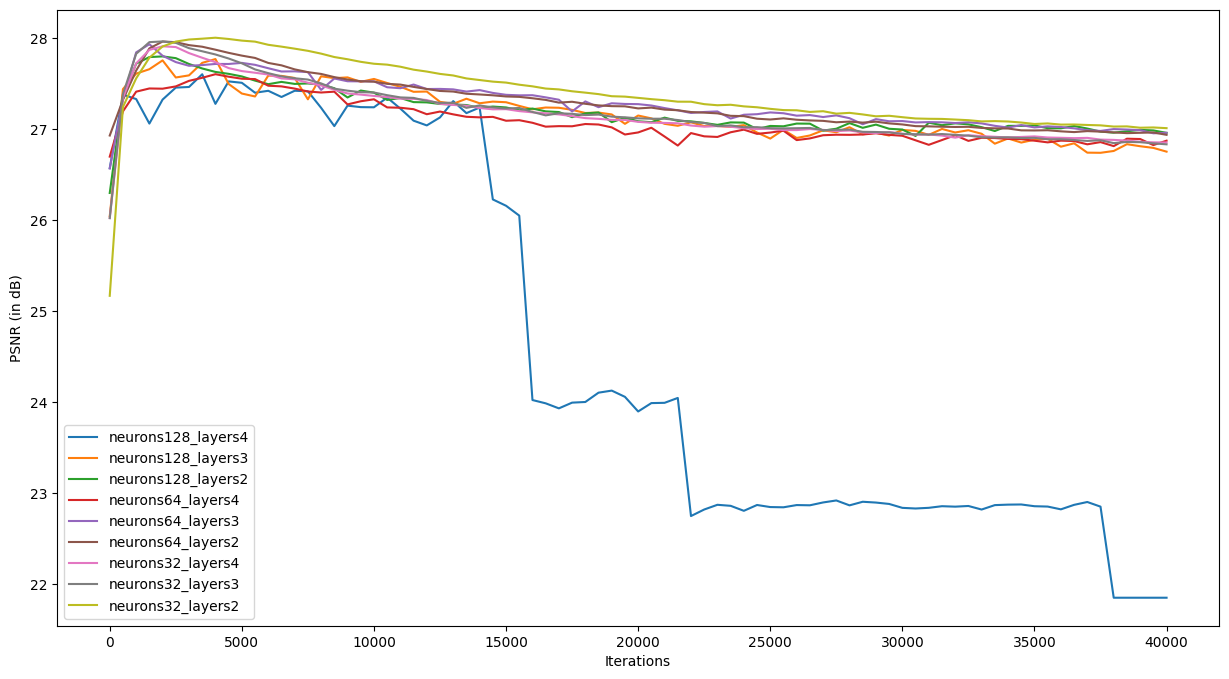

In [60]:
# Compare FullyFused MLP hyperparameters
ffMLPHyperparameterNames = [
    "neurons128_layers4",
    "neurons128_layers3",
    "neurons128_layers2",
    "neurons64_layers4",
    "neurons64_layers3",
    "neurons64_layers2",
    "neurons32_layers4",
    "neurons32_layers3",
    "neurons32_layers2"
]
ys = np.array([mean_results[name]["psnr_series"] for name in ffMLPHyperparameterNames])
fig, axes = create_line_graph(ys, ffMLPHyperparameterNames)


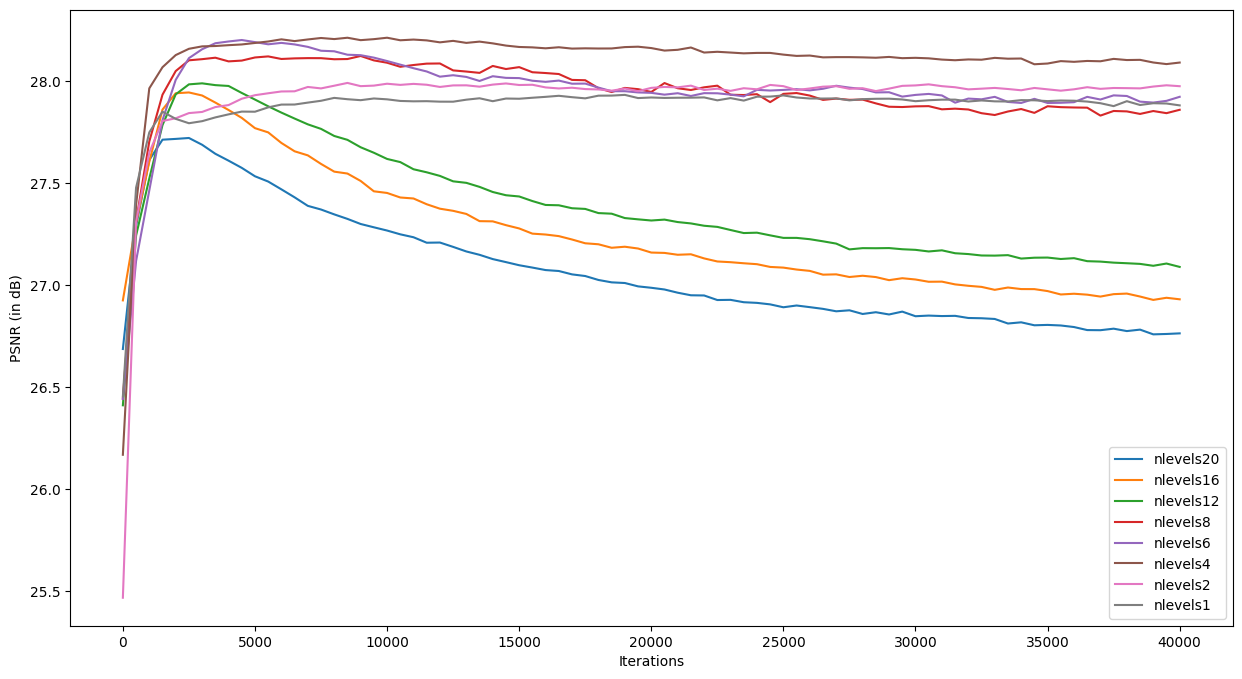

In [61]:
# Compare hashgrid nlevels hyperparameters

hashgridnlevels = [
    "nlevels20",
    "nlevels16",
    "nlevels12",
    "nlevels8",
    "nlevels6",
    "nlevels4",
    "nlevels2",
    "nlevels1",
]

ys = np.array([mean_results[name]["psnr_series"] for name in hashgridnlevels])
fig, axes = create_line_graph(ys, hashgridnlevels)

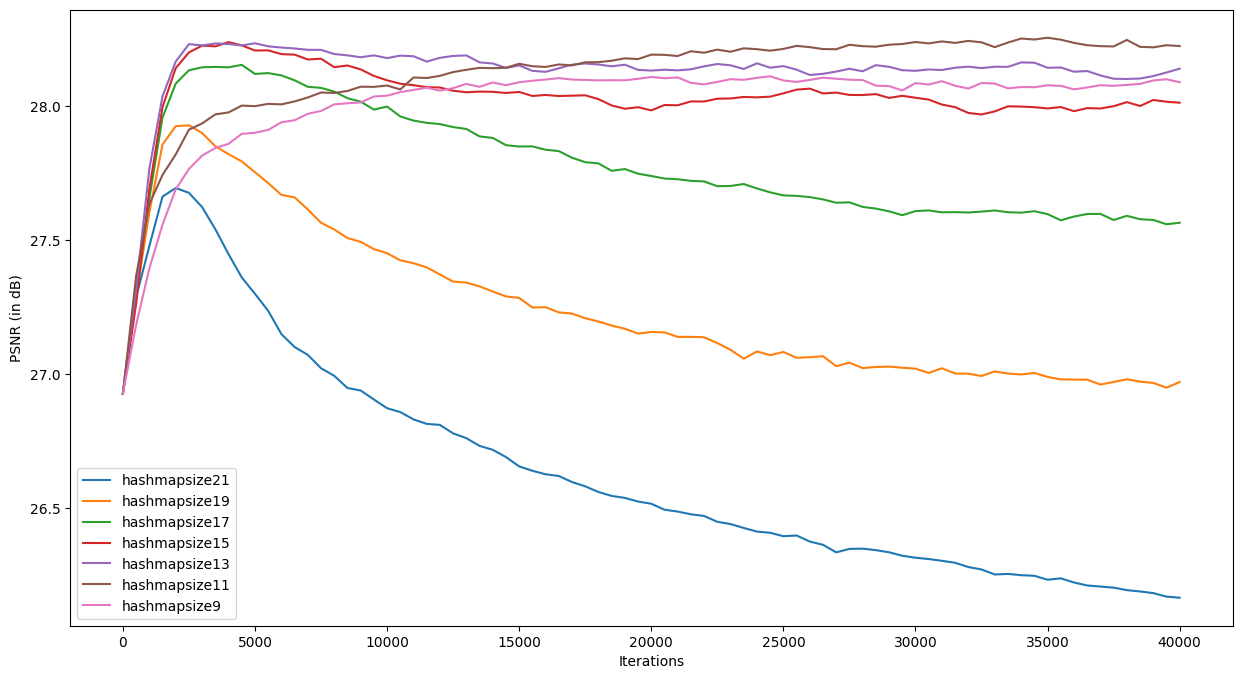

In [62]:
# Compare hashgrid hashmapsize hyperparameters

hashgridmapsizes = [
    "hashmapsize21",
    "hashmapsize19",
    "hashmapsize17",
    "hashmapsize15",
    "hashmapsize13",
    "hashmapsize11",
    "hashmapsize9",
]

ys = np.array([mean_results[name]["psnr_series"] for name in hashgridmapsizes])
fig, axes = create_line_graph(ys, hashgridmapsizes)

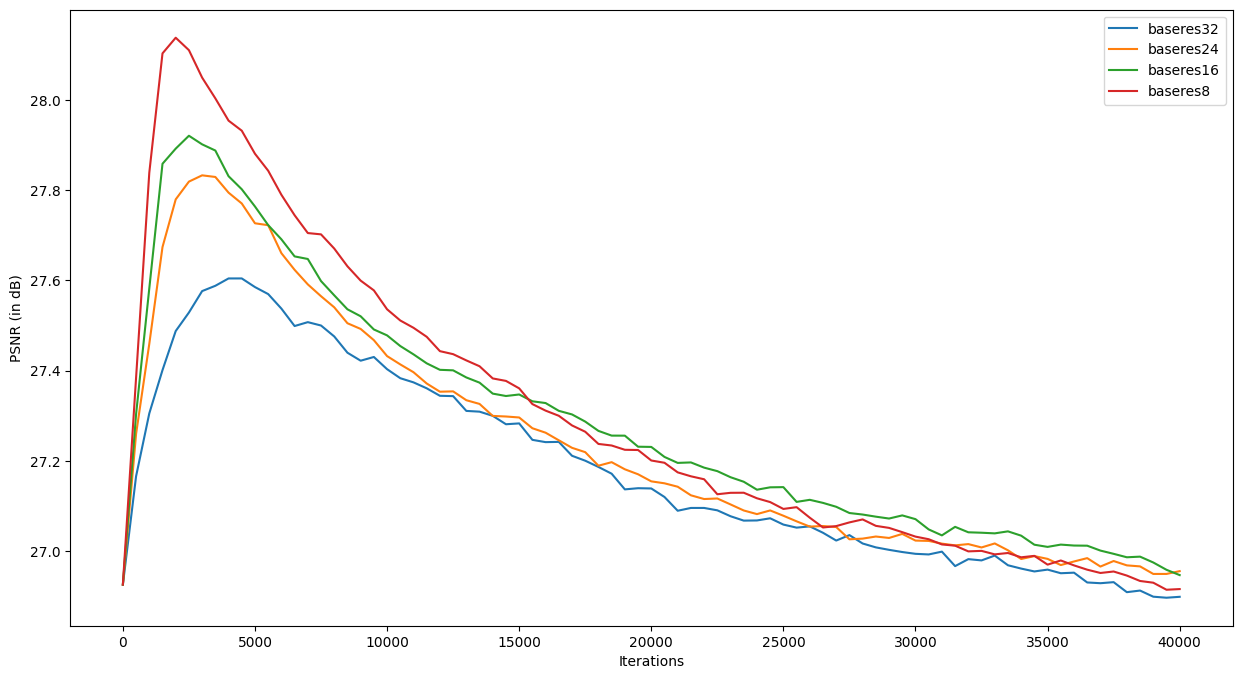

In [63]:
# Compare hashgrid baseres hyperparameters
hashgridbaseres = [
    "baseres32",
    "baseres24",
    "baseres16",
    "baseres8",
]

ys = np.array([mean_results[name]["psnr_series"] for name in hashgridbaseres])
fig, axes = create_line_graph(ys, hashgridbaseres)

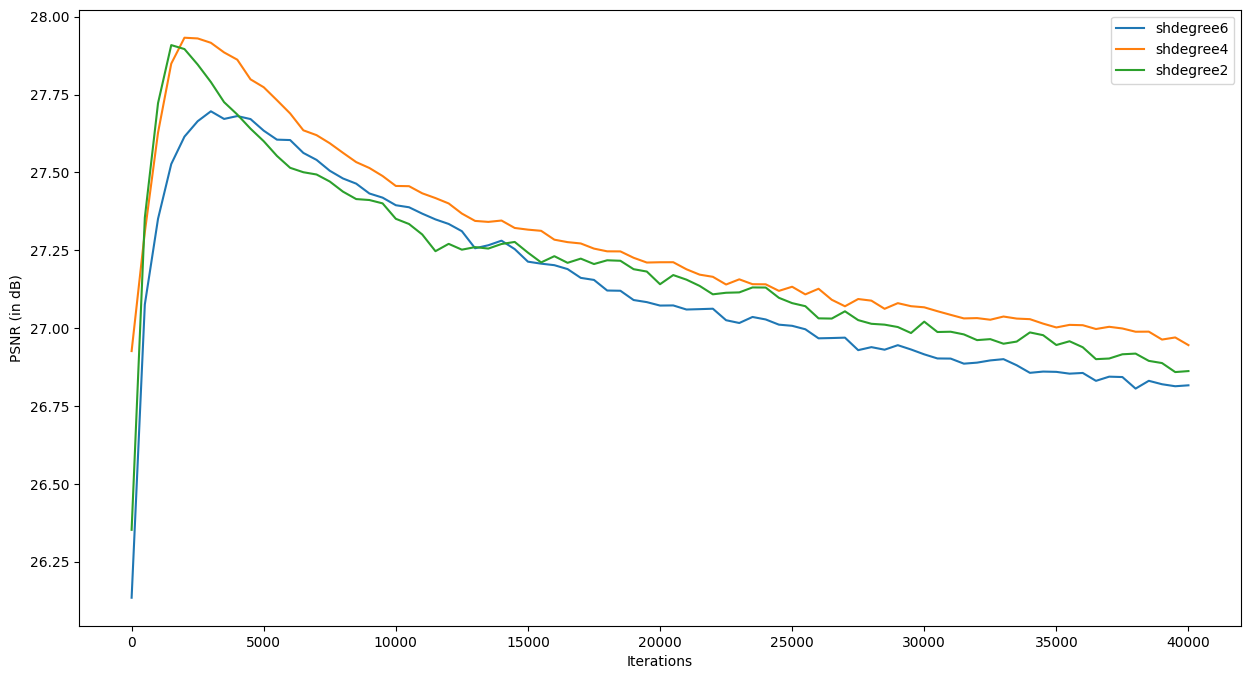

In [64]:
# Compare shdegree hyperparameters
shdegrees = [
    "shdegree6",
    "shdegree4",
    "shdegree2"
]

def create_group_graph(names: List[str], metric: str = "psnr_series") -> Tuple[Figure, Axes]:
    ys = np.array([mean_results[name][metric] for name in names])
    return create_line_graph(ys, names)

fig, axes = create_group_graph(shdegrees, "psnr_series")

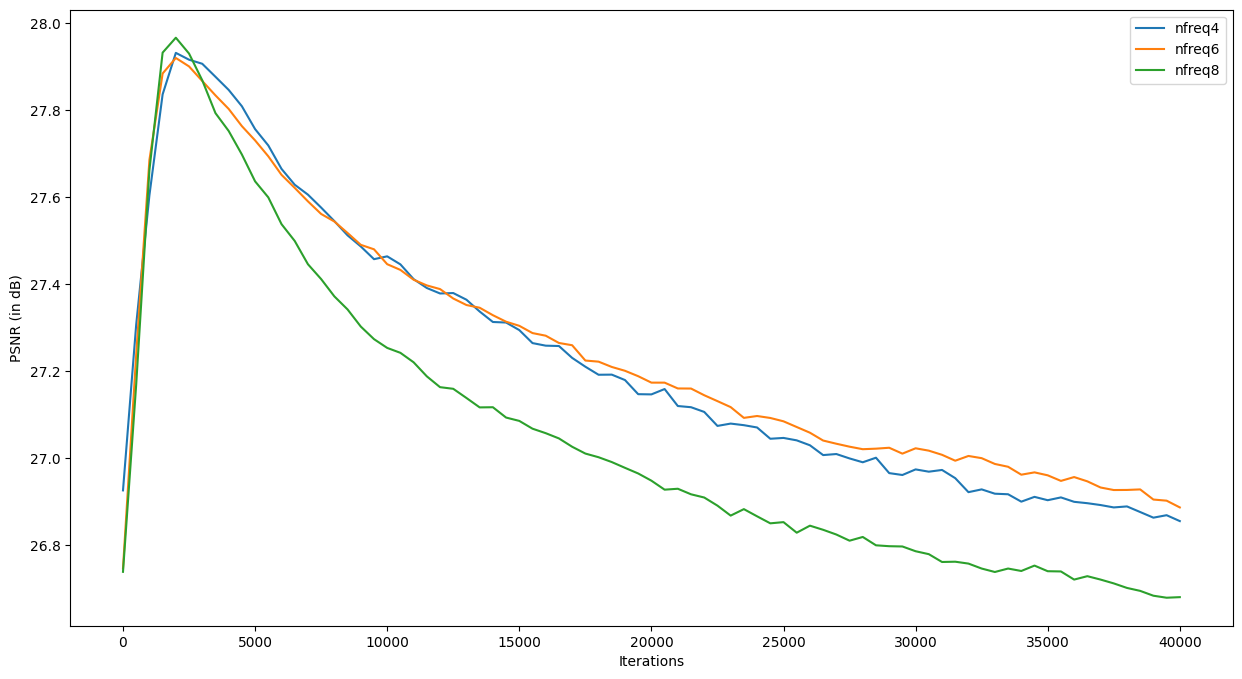

In [65]:
# Compare nfrequencies hyperparameters

nfreqs = [
    "nfreq4",
    "nfreq6",
    "nfreq8",
]

fig, axes = create_group_graph(nfreqs)

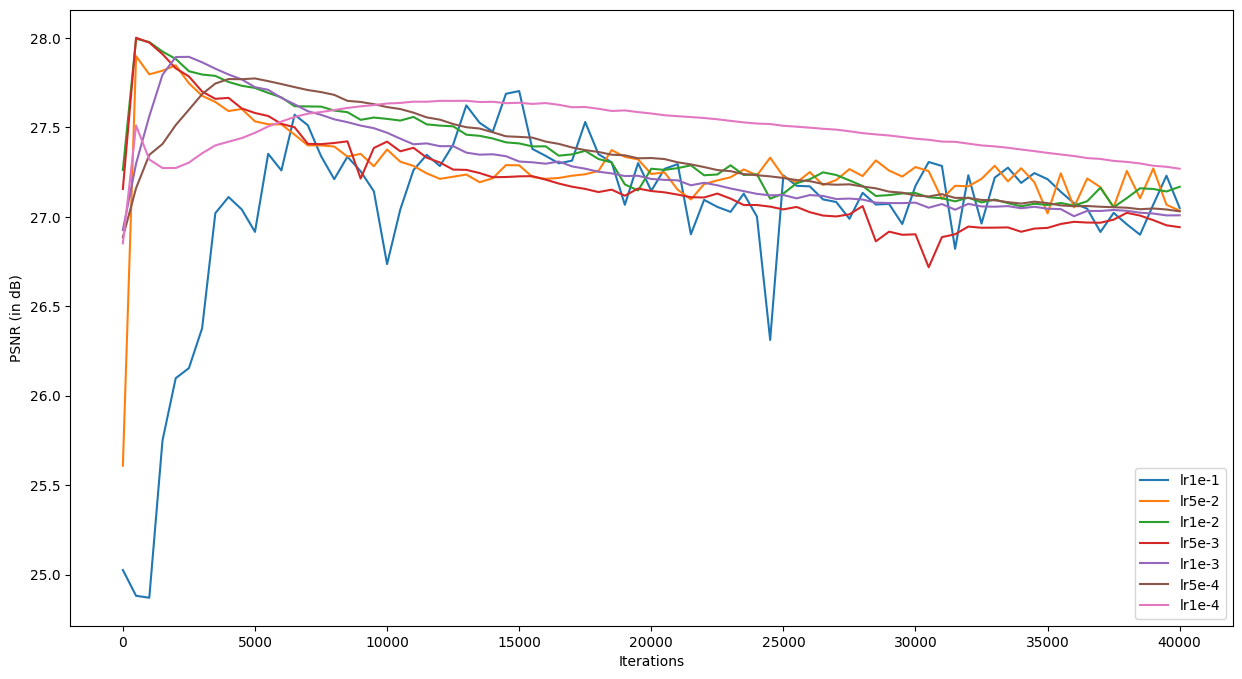

In [66]:
# Compare static lr hyperparameters

lrs = [
    "lr1e-1",
    "lr5e-2",
    "lr1e-2",
    "lr5e-3",
    "lr1e-3",
    "lr5e-4",
    "lr1e-4"
]

fig, axes = create_group_graph(lrs)

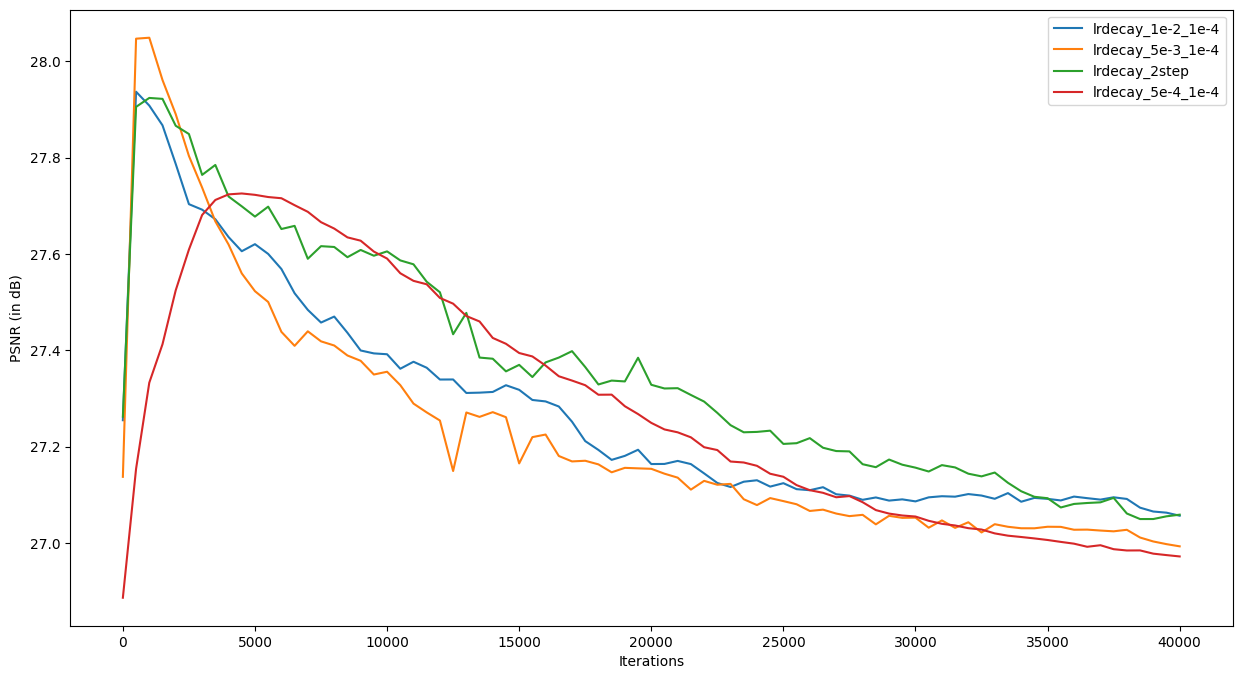

In [67]:
# Compare lr decay hyperparameters

lr_decays = [
    "lrdecay_1e-2_1e-4",
    "lrdecay_5e-3_1e-4",
    "lrdecay_2step",
    "lrdecay_5e-4_1e-4"
]

fig, axes = create_group_graph(lr_decays)

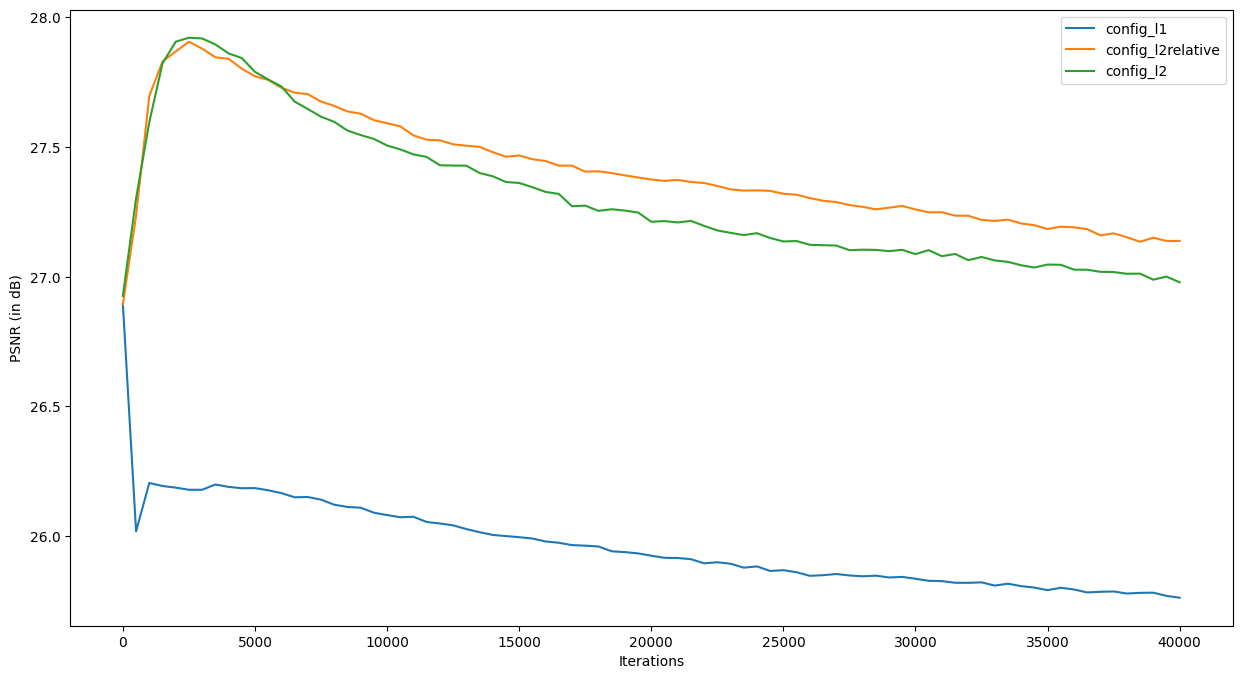

In [68]:
# Compare loss metric hyperparameters

loss_metrics = [
    "config_l1",
    "config_l2relative",
    "config_l2"
]

fig, axes = create_group_graph(loss_metrics)

In [69]:
# function to easily show tables


def create_group_table(names: List[str]) -> Table:

    colHeaders = ["mse", "psnr (in dB)", "final training loss", "final training ema loss", "training time (secs)"]
    colNames = ["mse", "psnr", "loss", "ema", "time"]
    fig, axes = plt.subplots(figsize=(12, len(names)))
    axes.axis("tight")
    axes.axis("off")

    table_entries = []
    for name in names:
        row = []
        for col in colNames:
            row.append(f"{mean_results[name][col]:.6f}")
        table_entries.append(row)

    table = axes.table(table_entries, 
                       rowLabels=names, 
                       colLabels=colHeaders,
                       cellLoc="center",
                       loc="center")
    table.scale(1, 1.15)
    return table

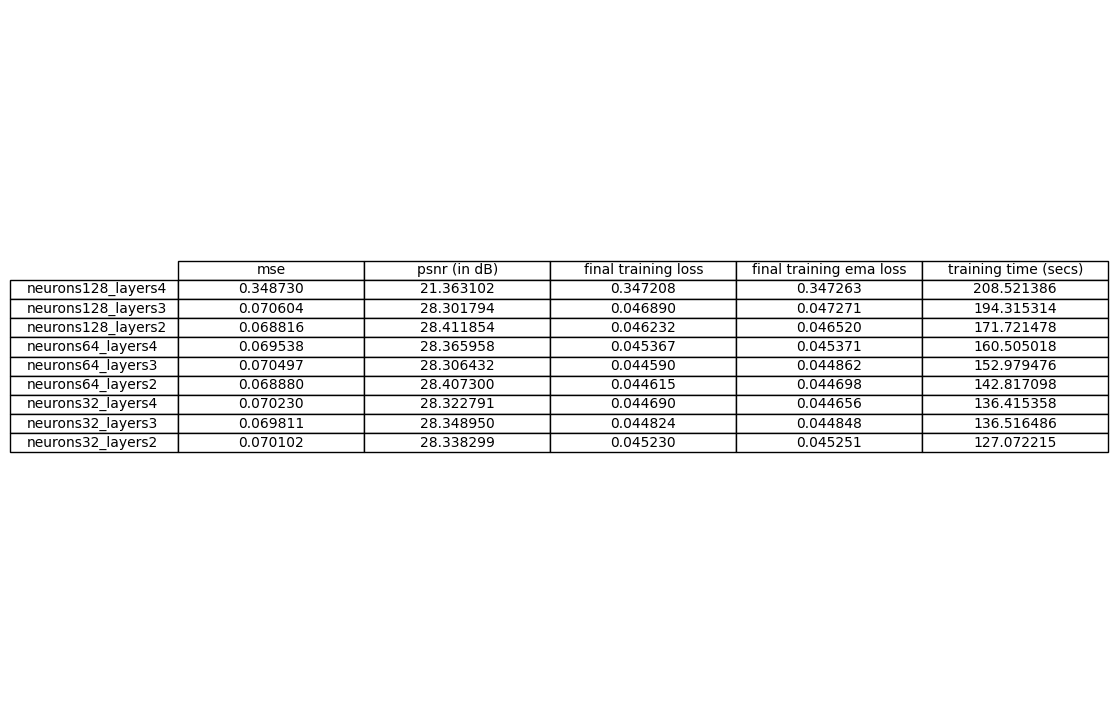

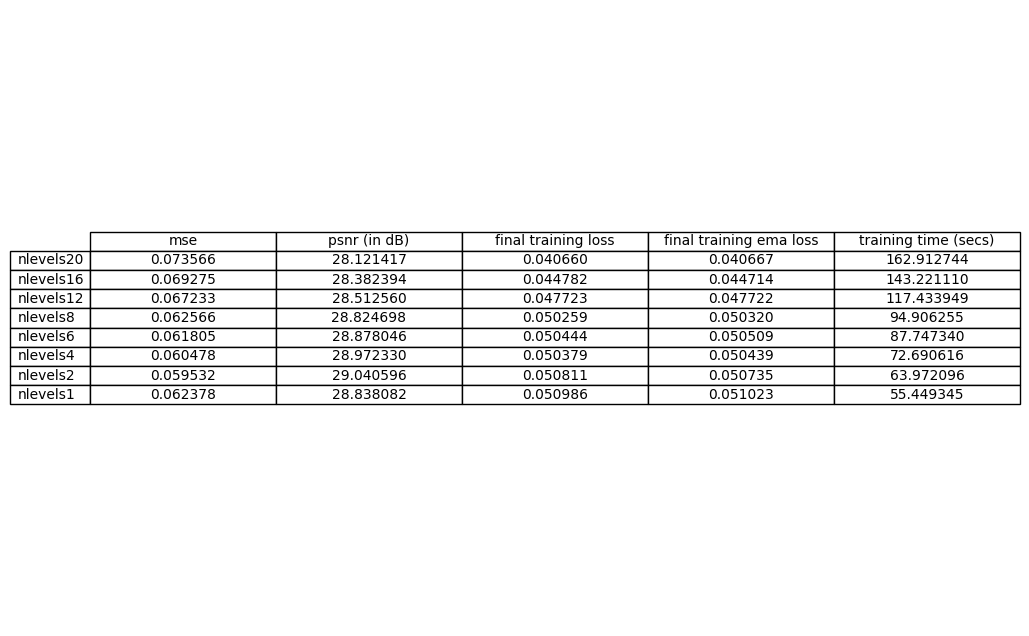

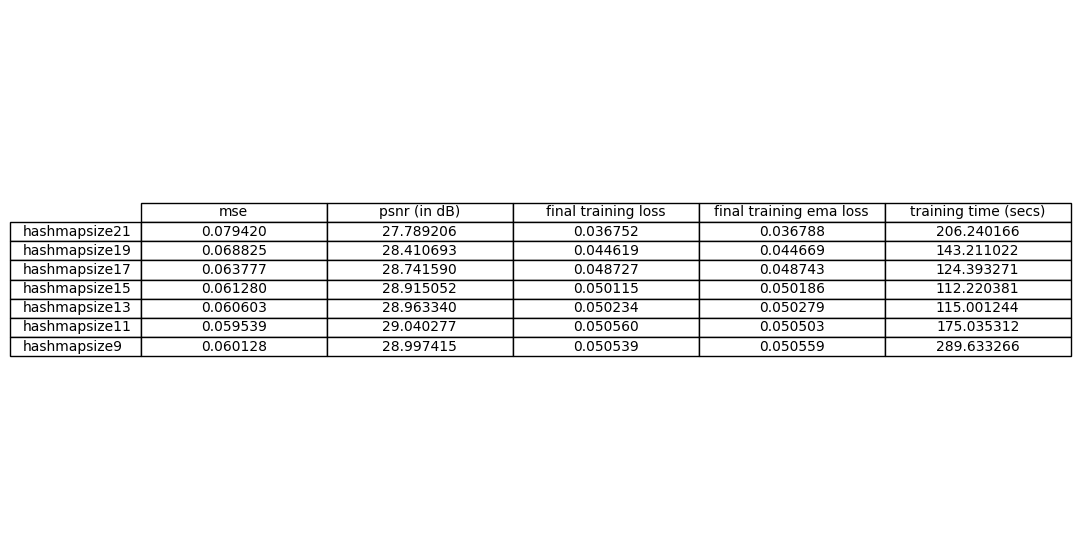

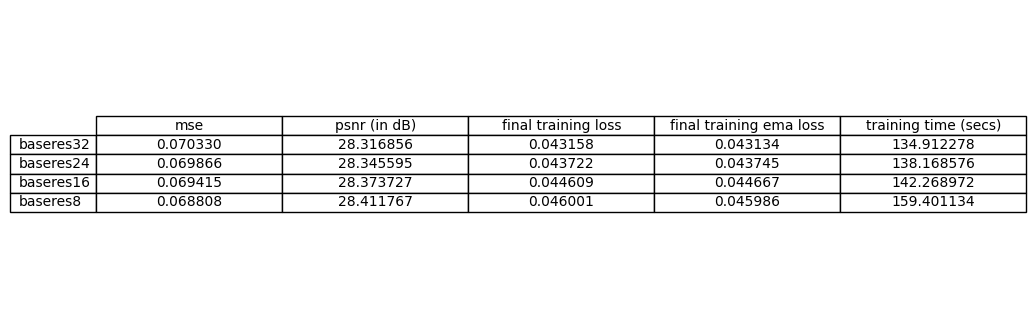

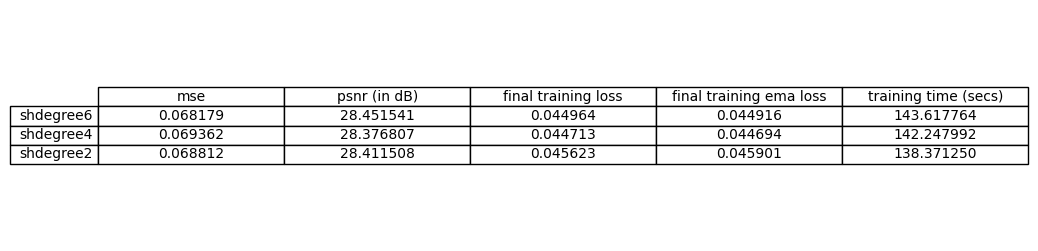

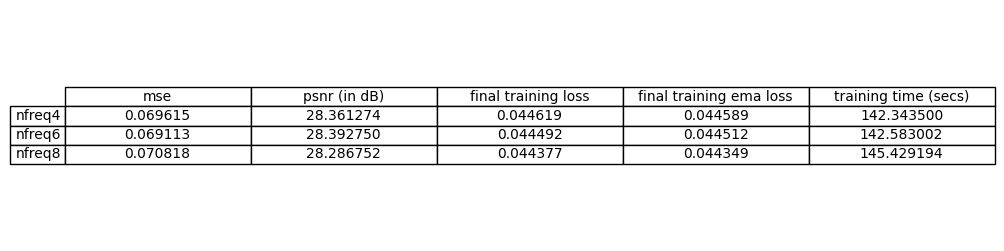

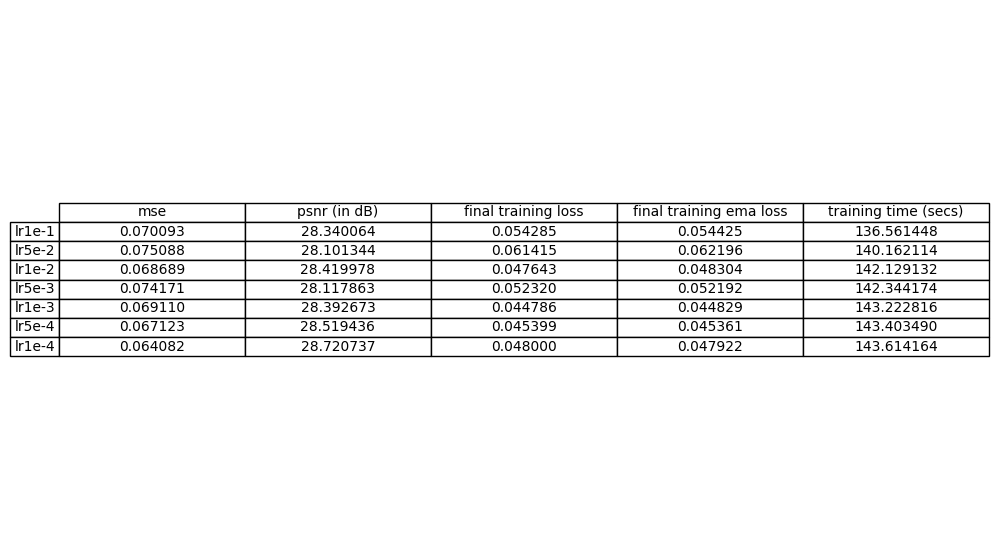

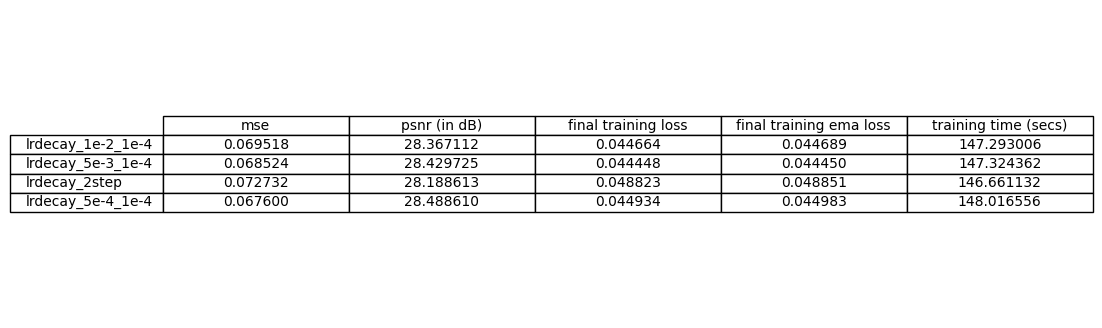

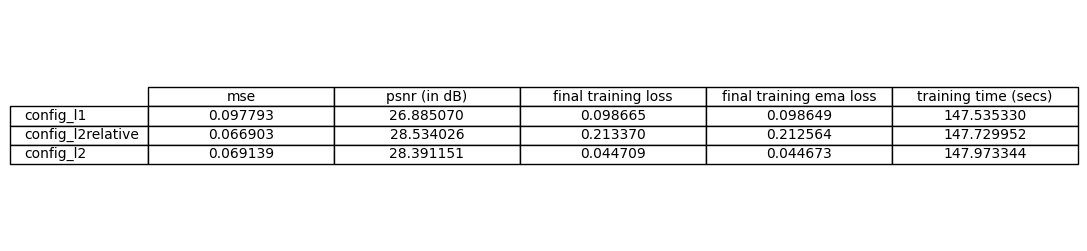

In [70]:
# create table for final validation result values

create_group_table(ffMLPHyperparameterNames)
create_group_table(hashgridnlevels)
create_group_table(hashgridmapsizes)
create_group_table(hashgridbaseres)
create_group_table(shdegrees)
create_group_table(nfreqs)
create_group_table(lrs)
create_group_table(lr_decays)
create_group_table(loss_metrics)

In [71]:
print(res_array[0]["neurons128_layers3"]["psnr"])
print(res_array[1]["neurons128_layers3"]["psnr"])
print(res_array[2]["neurons128_layers3"]["psnr"])
print(res_array[3]["neurons128_layers3"]["psnr"])
print(res_array[4]["neurons128_layers3"]["psnr"])
print(mean_results["neurons128_layers3"]["psnr"])

28.06181
28.317976
28.364813
28.296682
28.46769
28.3017942
